In [1]:
import utils.paths as d
import utils.utils as u
import utils.functions as f

from utils.utils import PALETTE, LEVEL1_COLORS, L2_COLORS
from utils.functions import apply_palette, show_palette
from matplotlib_scalebar.scalebar import ScaleBar
from spatialdata.transformations import Affine, set_transformation

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap


from spatialdata.models import TableModel
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import spatialdata as sd
import spatialdata_plot
import zarr
import anndata as ad
import os
import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=UserWarning)

print("Python version:", __import__('sys').version)
for m in (sc, sd, spatialdata_plot, zarr, ad):
    print(f"{m.__name__} version: {m.__version__}")

Python version: 3.11.17 (main, Oct  1 2026, 20:58:35) [MSC v.1944 64 bit (AMD64)]
scanpy version: 1.11.5
spatialdata version: 0.7.3
spatialdata_plot version: 0.4.0
zarr version: 3.1.6
anndata version: 0.12.19


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12364\291026288.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"{m.__name__} version: {m.__version__}")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12364\291026288.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f"{m.__name__} version: {m.__version__}")


In [2]:
PARENT_DIR = d.project_root
INPUT_DIR = d.preprocessed_dir
SDATA_DIR = d.preprocessed_dir
adata = sc.read_h5ad(os.path.join(INPUT_DIR, "adata_annotated_refined_10.h5ad"))

In [3]:
wt_1 = sd.read_zarr(SDATA_DIR / "wt_1.zarr")
wt_2 = sd.read_zarr(SDATA_DIR / "wt_2.zarr")
wt_3 = sd.read_zarr(SDATA_DIR / "wt_3.zarr")
wt_4 = sd.read_zarr(SDATA_DIR / "wt_4.zarr")
mut_1 = sd.read_zarr(SDATA_DIR / "mut_1.zarr")
mut_2 = sd.read_zarr(SDATA_DIR / "mut_2.zarr")
mut_3_path = SDATA_DIR / "mut_3.zarr"
mut_3 = sd.read_zarr(mut_3_path, selection=("shapes", "points"))
mut_3.tables["table"] = ad.read_zarr(str(mut_3_path / "tables" / "table"))
mut_4 = sd.read_zarr(SDATA_DIR / "mut_4.zarr")

sdatas = {
    "wt_1": wt_1, "wt_2": wt_2, "wt_3": wt_3, "wt_4": wt_4,
    "mut_1": mut_1, "mut_2": mut_2, "mut_3": mut_3, "mut_4": mut_4,
}

In [4]:
samples = [f'{g}_{i}' for g in ['wt', 'mut'] for i in range(1, 5)]
sdatas = {s: globals()[s] for s in samples}      # or: {s: sd.read_zarr(path) for s, path in paths.items()}

def link_table(sdata, ad_s, id_col='cell', shapes='cell_boundaries', name='table_annot'):
    shp = sdata[shapes]
    ad = ad_s.copy()
    ad.uns.pop('spatialdata_attrs', None)
    ad.obs['region_sd'] = pd.Categorical([shapes] * ad.n_obs)
    ad.obs['instance_id'] = ad.obs[id_col].astype(shp.index.dtype).values
    ids = ad.obs['instance_id']
    c = shp.loc[ids[ids.isin(shp.index)].values].geometry.centroid
    m = ids.isin(shp.index).values
    d = np.hypot(c.x.values - ad.obs['centroid_x'].values[m], c.y.values - ad.obs['centroid_y'].values[m])
    sdata[name] = TableModel.parse(ad, region=shapes, region_key='region_sd', instance_key='instance_id')
    return dict(n_cells=ad.n_obs, n_shapes=len(shp), unique=ids.is_unique,
                matched=round(m.mean(), 4), median_dist=round(float(np.median(d)), 3))

report = pd.DataFrame({s: link_table(sdatas[s], adata[adata.obs['sample'] == s]) for s in samples}).T
report

,n_cells,n_shapes,unique,matched,median_dist
wt_1,26871,27343,True,1.0,0.3
wt_2,24828,25154,True,1.0,0.345
wt_3,22654,23387,True,1.0,0.295
wt_4,30322,31126,True,1.0,0.311
mut_1,21469,21960,True,1.0,0.315
mut_2,23470,24114,True,1.0,0.295
mut_3,25948,26634,True,1.0,0.323
mut_4,25163,26055,True,1.0,0.322


Orient samples

In [5]:
def orient_sdata(sdata, flip=None, rotate=0, elements=("cell_boundaries",), cs="global"):
    """Mirror/rotate SpatialData elements around the tissue centre (non-destructive).
    flip: "x" (left-right), "y" (up-down), "xy" or None; rotate: degrees, applied after flip.
    Each call replaces the previous transform, so re-running doesn't stack."""
    minx, miny, maxx, maxy = sdata.shapes[elements[0]].total_bounds
    c = np.array([(minx + maxx) / 2, (miny + maxy) / 2])

    F = np.diag([-1 if flip and "x" in flip else 1,
                 -1 if flip and "y" in flip else 1])
    a = np.deg2rad(rotate)
    R = np.array([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]]) @ F
    t = c - R @ c                                   # keep the tissue centred in place

    M = np.array([[R[0, 0], R[0, 1], t[0]],
                  [R[1, 0], R[1, 1], t[1]],
                  [0, 0, 1]])
    for el in elements:
        set_transformation(sdata[el], Affine(M, input_axes=("x", "y"), output_axes=("x", "y")),
                           to_coordinate_system=cs)

In [6]:
transforms = {"wt_3": {"flip": "x"}, "wt_4": {"flip": "x"}, "mut_2": {"flip": "x"}}

for s in sdatas:
    t = transforms.get(s, {})
    orient_sdata(sdatas[s], flip=t.get("flip"), rotate=t.get("rotate", 0))

In [7]:
groups = [t for t in L2_COLORS if t in set(adata.obs['annotation'])]
palette = [L2_COLORS[t] for t in groups]

In [8]:
expr_cmap = LinearSegmentedColormap.from_list(
    "gray_ember",
    [
        (0.00, "#D3D3D3"),   # no expression – light gray
        (0.05, "#F7C548"),   # lowest – warm yellow
        (0.25, "#F5A623"),   # low – amber
        (0.50, "#EC7A1C"),   # mid – orange
        (0.75, "#D2451E"),   # high – red-orange
        (1.00, "#8E1B1B"),   # max – deep brick red
    ],
    N=256,
)
expr_cmap.set_under("#D3D3D3")

In [ ]:
gene, cmap = "Runx2", expr_cmap

# shared colour scale across all samples (99th percentile, so a few outliers don't wash it out)
vals = np.concatenate([np.asarray(sdatas[s]["table"][:, gene].X.todense()
                                  if hasattr(sdatas[s]["table"].X, "todense")
                                  else sdatas[s]["table"][:, gene].X).ravel()
                       for c in ["wt", "mut"] for s in [f"{c}_{i}" for i in range(1, 5)]])
norm = Normalize(vmin=0, vmax=np.percentile(vals, 99))
span = f.common_span(sdatas, samples)   # same µm window in every panel -> scale bars of equal length

for cond in ['wt', 'mut']:
    fig, axes = plt.subplots(1, 4, figsize=(25, 10))
    for ax, i in zip(axes, range(1, 5)):
        s = f'{cond}_{i}'
        sdatas[s].pl.render_shapes('cell_boundaries', color=gene, table_name="table",
                                   cmap=cmap, norm=norm).pl.show(ax=ax)
        ax.set_axis_off()
        f.same_scale(ax, sdatas[s], span)
        ax.add_artist(ScaleBar(dx=1, units="um", fixed_value=100, fixed_units="um",
                               location="lower right", frameon=False))
        ax.set_title(s, fontsize=14)

    for extra in [a for a in fig.axes if a not in axes]:   # drop per-panel colorbars
        extra.remove()
    plt.tight_layout()
    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes, shrink=0.5, label=f"{gene} expression")
    fig.suptitle("")
    plt.show()

In [ ]:
gene, cmap = "Satb2", expr_cmap

# shared colour scale across all samples (99th percentile, so a few outliers don't wash it out)
vals = np.concatenate([np.asarray(sdatas[s]["table"][:, gene].X.todense()
                                  if hasattr(sdatas[s]["table"].X, "todense")
                                  else sdatas[s]["table"][:, gene].X).ravel()
                       for c in ["wt", "mut"] for s in [f"{c}_{i}" for i in range(1, 5)]])
norm = Normalize(vmin=0, vmax=np.percentile(vals, 99))
span = f.common_span(sdatas, samples)   # same µm window in every panel -> scale bars of equal length

for cond in ['wt', 'mut']:
    fig, axes = plt.subplots(1, 4, figsize=(25, 10))
    for ax, i in zip(axes, range(1, 5)):
        s = f'{cond}_{i}'
        sdatas[s].pl.render_shapes('cell_boundaries', color=gene, table_name="table",
                                   cmap=cmap, norm=norm).pl.show(ax=ax)
        ax.set_axis_off()
        f.same_scale(ax, sdatas[s], span)
        ax.add_artist(ScaleBar(dx=1, units="um", fixed_value=100, fixed_units="um",
                               location="lower right", frameon=False))
        ax.set_title(s, fontsize=14)

    for extra in [a for a in fig.axes if a not in axes]:   # drop per-panel colorbars
        extra.remove()
    plt.tight_layout()
    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes, shrink=0.5, label=f"{gene} expression")
    fig.suptitle("")
    plt.show()

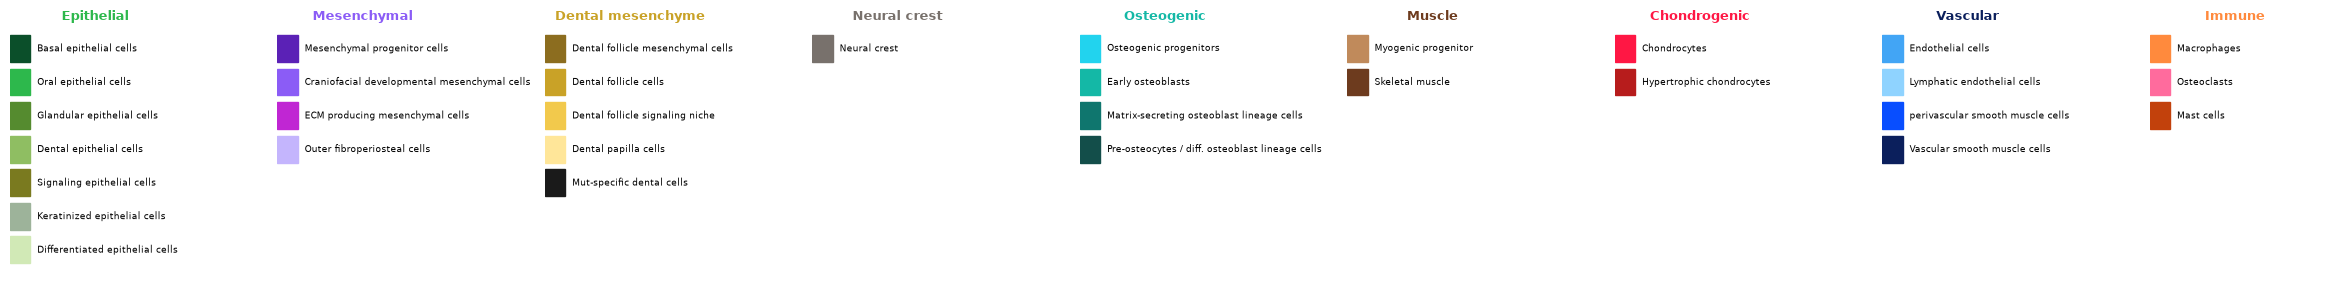

In [ ]:
f.show_palette()

In [ ]:
span = f.common_span(sdatas, samples)   # same µm window in every panel -> scale bars of equal length

for cond in ['wt', 'mut']:
    fig, axes = plt.subplots(1, 4, figsize=(20, 10))
    for ax, i in zip(axes, range(1, 5)):
        s = f'{cond}_{i}'
        sdatas[s].pl.render_shapes('cell_boundaries', color='annotation', table_name='table_annot',
                                   groups=groups, palette=palette).pl.show(ax=ax)
        if ax.get_legend(): ax.get_legend().remove()
        ax.set_axis_off()
        f.same_scale(ax, sdatas[s], span)
    
        ax.add_artist(ScaleBar(
            dx=1, units="um", fixed_value=100, fixed_units="um",
            location="lower right", frameon=False,
        ))
        ax.set_title(s, fontsize=14)
    fig.suptitle(cond.upper(), fontsize=18, weight='bold') 
    plt.tight_layout(); plt.show()

Closer look on **wt_2** and **mut_2**

In [14]:
f.orient_sdata(sdatas['wt_2'], flip=None, rotate=90)

AttributeError: module 'utils.functions' has no attribute 'orient_sdata'

In [ ]:
# fig, ax = plt.subplots(figsize=(5, 5))
# sdatas['mut_3'].pl.render_shapes('cell_boundaries', color="#D3D3D3").pl.show(frameon=False, ax=ax)
# if ax.get_legend(): ax.get_legend().remove()
# ax.set_axis_off()
# y0, y1 = ax.get_ylim()
# ax.set_ylim(y0 - 0.15 * (y1 - y0), y1)
# ax.add_artist(ScaleBar(
#             dx=1, units="um", fixed_value=100, fixed_units="um",
#             location="lower right", frameon=False,
#         ))

In [ ]:
# fig, ax = plt.subplots(figsize=(20, 20))
# sdatas['mut_3'].pl.render_shapes(
#     'cell_boundaries', color='annotation', table_name='table_annot',
#     groups=groups, palette=palette,
# ).pl.show(ax=ax, frameon=False)
# if ax.get_legend():
#     ax.get_legend().remove()
# plt.show()

In [ ]:
# sdatas['wt_2'].pl.render_shapes('cell_boundaries', color='annotation', table_name='table_annot',groups=groups, palette=palette).pl.show(figsize=(20, 20))

In [ ]:
sdatas['mut_3'].shapes['cell_boundaries'].total_bounds 

array([ 1572.21875 , 19795.859375,  2811.21875 , 22312.859375])

### CROPP USED

In [ ]:
crop_osteochondro_wt_2 = {"x_min": 1200, "y_max": 16800, "y_min": 16000, "x_max": 2000}
crop_osteochondro_mut_3 = {"x_min": 1850, "x_max": 2450, "y_min": 20650, "y_max": 21250}
crop_tooth_wt_2 = {"x_min": 1050, "x_max": 1800, "y_min": 16600, "y_max": 17500}
crop_tooth_mut_3 = {"x_min": 1650, "x_max": 2200, "y_min": 21000, "y_max": 21700}

sdatas['wt_2_tooth'] = f.crop(sdatas['wt_2'], crop_tooth_wt_2, units="microns", target="global")

In [ ]:
keep = ["Dental epithelial cells", "Neural crest", "Osteoclasts", "Chondrocytes", "Hypertrophic chondrocytes", "Mut-specific dental cells",
        "Early osteoblasts", "Pre-osteocytes / diff. osteoblast lineage cells", "Macrophages", "Matrix-secreting osteoblast lineage cells", 
        "Osteogenic progenitors", "Basal epithelial cells", "Oral epithelial cells", "Dental epithelial cells",
        "Differentiated epithelial cells", "Dental follicle mesenchymal cells",
        "Endothelial cells", "Vascular smooth muscle cells", "Dental papilla cells",
        "Outer fibroperiosteal cells", "Dental follicle mesenchymal cells", "Dental follicle cells", "Dental follicle signaling niche"]          # cell types to colour

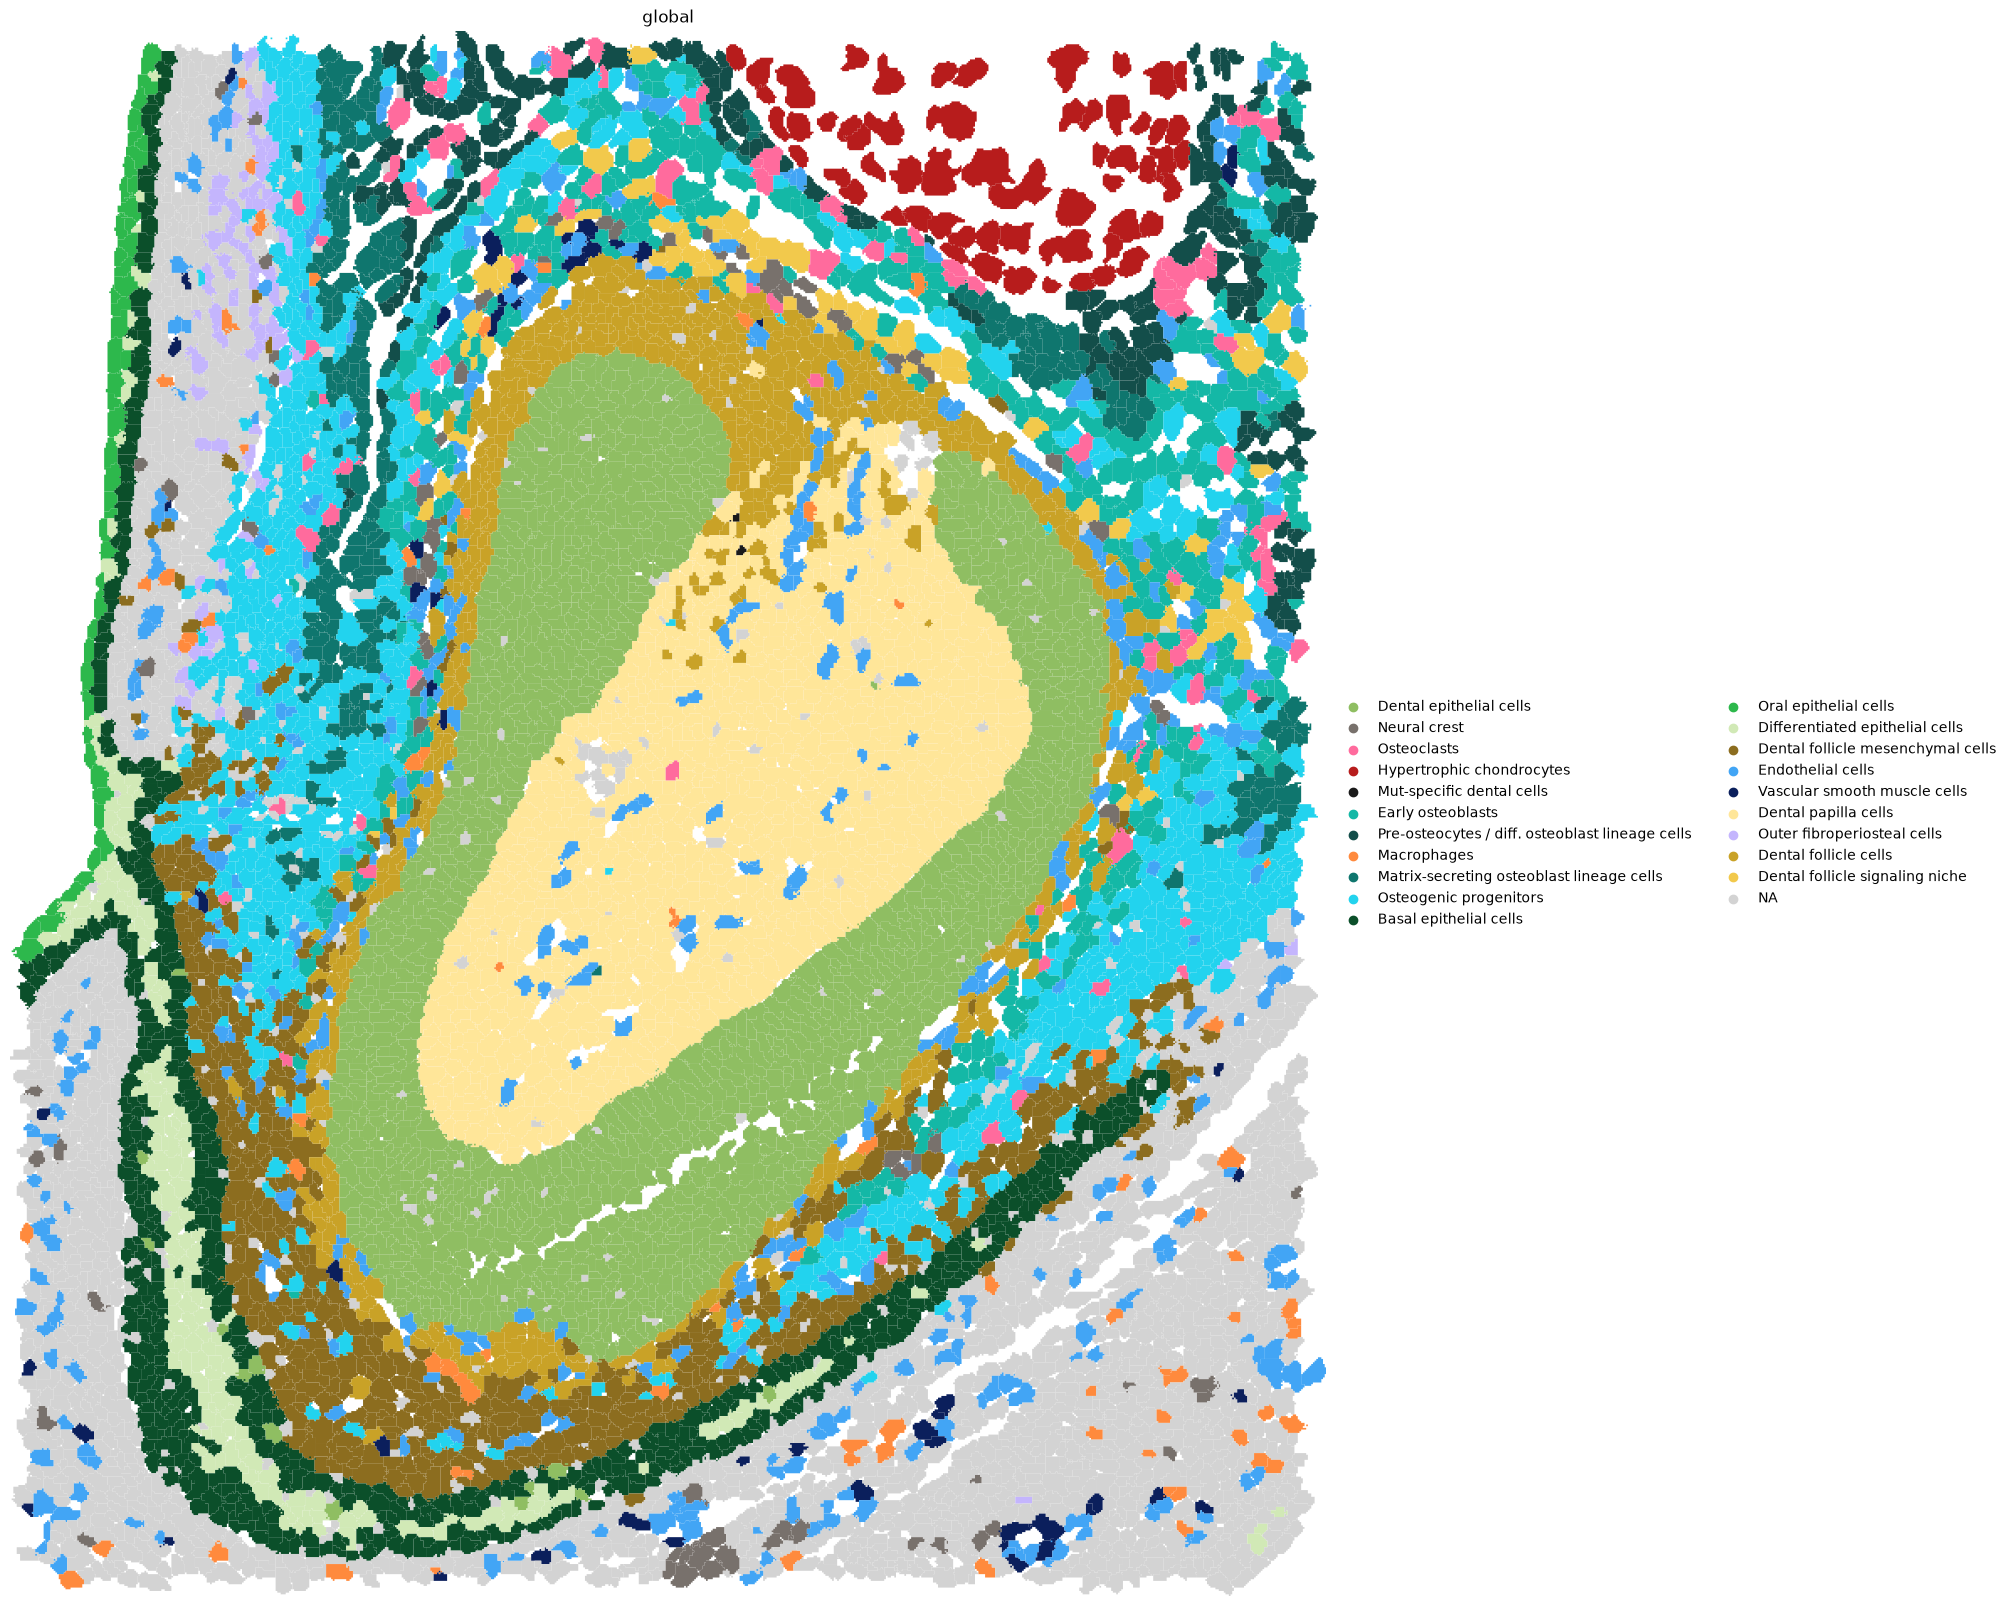

In [ ]:
sdatas['wt_2_tooth'].pl.render_shapes(
    'cell_boundaries', color='annotation', table_name='table_annot',
    groups=keep, palette=[L2_COLORS[g] for g in keep], na_color="#D3D3D3",
).pl.show(figsize=(20, 20), frameon=False)